# AI Application Example III: Multi-Class Gas Classification
## Gas Sensor Array Drift at Different Concentrations

**V1 objective:** parse the UCI `.dat` files, validate the dataset, perform exploratory analysis, and establish a leakage-aware modelling foundation.

**Classification target:** six gases: Ethanol, Ethylene, Ammonia, Acetaldehyde, Acetone, and Toluene.

**Primary predictors:** 128 sensor-derived features.

**Metadata retained for analysis:** batch and concentration. They are not primary predictors.


In [ ]:
# 1. Imports and reproducibility
import re
import zipfile
import warnings
import time
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Locate and extract the dataset

The notebook expects the uploaded UCI ZIP. It searches common paths so it can also be moved to Colab.


In [ ]:
# 2. Locate ZIP and extract
candidates = [
    Path("/content/gas+sensor+array+drift+dataset+at+different+concentrations.zip"),
    Path("C:\\Users\\srian\\Documents\\GitHub\\42172 Introduction to Artificial Intelligence\\Data\\gas+sensor+array+drift+dataset+at+different+concentrations.zip"),
]
zip_path = next((p for p in candidates if p.exists()), None)
if zip_path is None:
    raise FileNotFoundError("Upload the UCI ZIP or update the candidate paths.")

extract_dir = Path("/mnt/data/gas_sensor_dataset")
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

batch_files = sorted(extract_dir.rglob("batch*.dat"))
print("ZIP:", zip_path)
print("Batch files:", len(batch_files))
for p in batch_files:
    print(" ", p.relative_to(extract_dir))


ZIP: C:\Users\srian\Documents\GitHub\42172 Introduction to Artificial Intelligence\Data\gas+sensor+array+drift+dataset+at+different+concentrations.zip
Batch files: 10
  batch1.dat
  batch10.dat
  batch2.dat
  batch3.dat
  batch4.dat
  batch5.dat
  batch6.dat
  batch7.dat
  batch8.dat
  batch9.dat


## 3. Parse the `.dat` files

Each row contains a gas class, concentration, and 128 `feature:value` entries. The source batch number is retained so that later experiments can investigate sensor drift.


In [ ]:
# 3. Parse all batch files
GAS_MAPPING = {
    1: "Ethanol",
    2: "Ethylene",
    3: "Ammonia",
    4: "Acetaldehyde",
    5: "Acetone",
    6: "Toluene",
}
feature_cols = [f"feature_{i}" for i in range(1, 129)]
records = []

for path in batch_files:
    m = re.search(r"batch(\d+)\.dat$", path.name, re.I)
    if not m:
        continue
    batch_id = int(m.group(1))

    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for line_no, line in enumerate(f, 1):
            tokens = line.strip().split()
            if not tokens:
                continue

            class_id_text, concentration_text = tokens[0].split(";")
            class_id = int(class_id_text)

            row = {
                "batch": batch_id,
                "class_id": class_id,
                "gas": GAS_MAPPING[class_id],
                "concentration_ppmv": float(concentration_text),
            }

            for token in tokens[1:]:
                idx, value = token.split(":")
                row[f"feature_{int(idx)}"] = float(value)

            records.append(row)

df = pd.DataFrame(records)

for col in feature_cols:
    if col not in df.columns:
        df[col] = np.nan

df = df[["batch", "class_id", "gas", "concentration_ppmv"] + feature_cols]

print("Shape:", df.shape)
display(df.head())


Shape: (13910, 132)


,batch,class_id,gas,concentration_ppmv,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,...,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128
0,1,1,Ethanol,10.0,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,...,-1.071137,-3.037772,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529
1,1,1,Ethanol,20.0,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,...,-1.530519,-1.994993,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225
2,1,1,Ethanol,30.0,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,...,-2.384784,-2.867291,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.348370
3,1,1,Ethanol,40.0,42825.9883,3.451192,12.113940,16.266853,39.910056,-7.849409,...,-2.607199,-3.058086,6147.4744,5.501071,1.981933,3.569823,4.049197,-1.432205,-2.146158,-2.488957
4,1,1,Ethanol,50.0,58151.1757,4.194839,11.455096,15.715298,17.654915,-11.083364,...,-3.594763,-4.181920,8158.6449,7.174334,1.993808,3.829303,4.402448,-1.930107,-2.931265,-4.088756


## 4. Dataset integrity audit

This section verifies the structure before any modelling.


In [ ]:
# 4. Integrity checks
print("Rows:", len(df))
print("Columns:", len(df))
print("Sensor features:", len(feature_cols))
print("Classes:", sorted(df["gas"].unique()))
print("Class IDs:", sorted(df["class_id"].unique()))
print("Missing cells:", int(df.isna().sum().sum()))
print("Infinite numeric cells:", int(np.isinf(df.select_dtypes(include=np.number)).to_numpy().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

assert len(feature_cols) == 128
assert set(df["class_id"].unique()) == set(GAS_MAPPING)
assert set(df["gas"].unique()) == set(GAS_MAPPING.values())


Rows: 13910
Columns: 13910
Sensor features: 128
Classes: ['Acetaldehyde', 'Acetone', 'Ammonia', 'Ethanol', 'Ethylene', 'Toluene']
Class IDs: [1, 2, 3, 4, 5, 6]
Missing cells: 0
Infinite numeric cells: 0
Duplicate rows: 0


## 5. Class distribution

Macro-averaged metrics will be retained for model comparison because they give each gas class equal weight.


,gas,count,percentage
0,Acetone,3009,21.631919
1,Ethylene,2926,21.035226
2,Ethanol,2565,18.439971
3,Acetaldehyde,1936,13.918045
4,Toluene,1833,13.177570
5,Ammonia,1641,11.797268


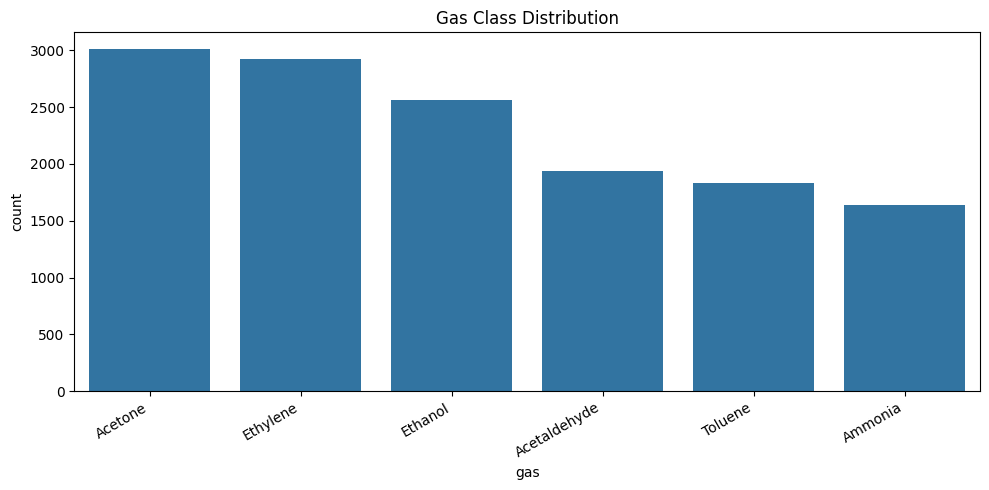

In [ ]:
# 5. Class distribution
class_counts = df["gas"].value_counts().rename_axis("gas").reset_index(name="count")
class_counts["percentage"] = 100 * class_counts["count"] / len(df)
display(class_counts)

plt.figure(figsize=(10,5))
sns.barplot(data=class_counts, x="gas", y="count")
plt.title("Gas Class Distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 6. Batch analysis

Batch is retained as metadata rather than a predictive feature. This allows later investigation of temporal sensor drift.


,batch,count
0,1,445
1,2,1244
2,3,1586
3,4,161
4,5,197
5,6,2300
6,7,3613
7,8,294
8,9,470
9,10,3600


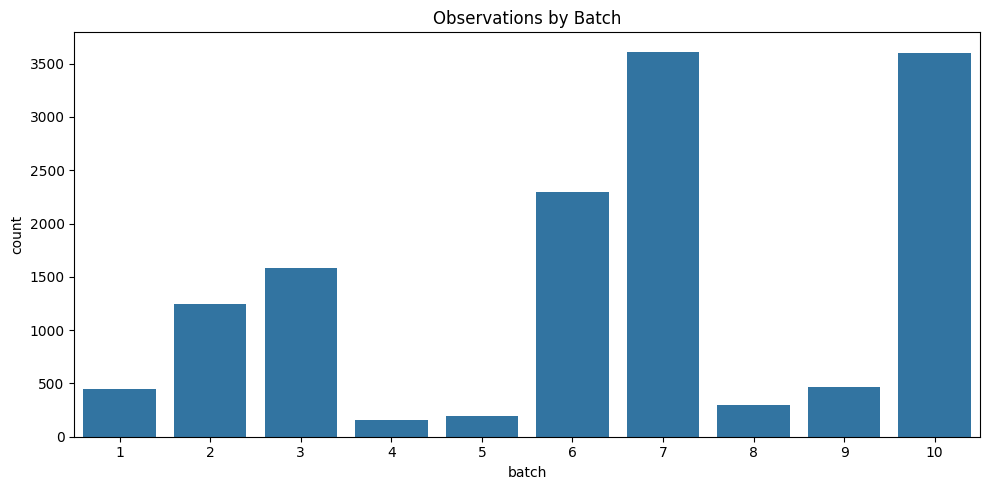

gas,Acetaldehyde,Acetone,Ammonia,Ethanol,Ethylene,Toluene
batch,,,,,,
1,30,70,83,90,98,74
2,109,532,100,164,334,5
3,240,275,216,365,490,0
4,30,12,12,64,43,0
5,46,63,20,28,40,0
6,29,606,110,514,574,467
7,744,630,360,649,662,568
8,33,143,40,30,30,18
9,75,78,100,61,55,101


In [ ]:
# 6. Batch distribution and gas-by-batch table
batch_counts = df["batch"].value_counts().sort_index().rename_axis("batch").reset_index(name="count")
display(batch_counts)

plt.figure(figsize=(10,5))
sns.barplot(data=batch_counts, x="batch", y="count")
plt.title("Observations by Batch")
plt.tight_layout()
plt.show()

display(pd.crosstab(df["batch"], df["gas"]))


## 7. Concentration analysis

Concentration is deliberately excluded from the primary predictor matrix. We inspect it here because it is an experimental condition that may influence sensor responses.


Unique concentrations:


,concentration_ppmv
0,1.0
1,2.5
2,5.0
3,10.0
4,12.0
5,15.0
6,20.0
7,25.0
8,30.0
9,35.0


,count,nunique,min,max,mean,std
gas,,,,,,
Acetaldehyde,1936,37,2.5,300.0,126.318440,76.709007
Acetone,3009,47,10.0,1000.0,228.565969,217.380679
Ammonia,1641,44,2.5,1000.0,323.548141,272.016672
Ethanol,2565,35,2.5,600.0,114.950292,86.637492
Ethylene,2926,38,2.5,300.0,116.104751,79.890224
Toluene,1833,32,1.0,230.0,47.663121,32.576269


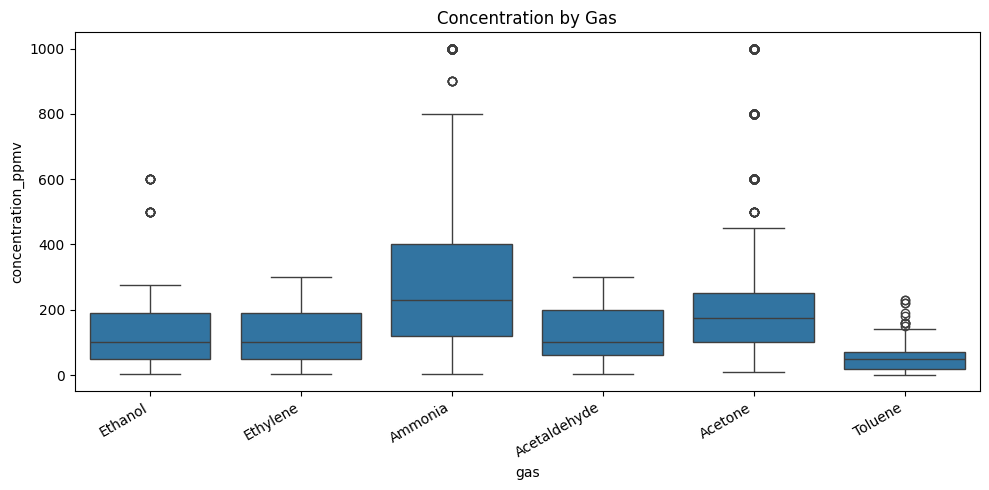

In [ ]:
# 7. Concentration analysis
print("Unique concentrations:")
display(pd.DataFrame({"concentration_ppmv": np.sort(df["concentration_ppmv"].unique())}))

display(
    df.groupby("gas")["concentration_ppmv"]
      .agg(["count","nunique","min","max","mean","std"])
      .sort_index()
)

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="gas", y="concentration_ppmv")
plt.title("Concentration by Gas")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 8. Sensor feature quality

We inspect missingness, variance and descriptive statistics before preprocessing.


In [ ]:
# 8. Feature quality
summary = df[feature_cols].describe().T
summary["missing"] = df[feature_cols].isna().sum()
summary["nunique"] = df[feature_cols].nunique()
summary["variance"] = df[feature_cols].var()
display(summary)

print("Zero-variance features:",
      sum(df[c].nunique(dropna=False) <= 1 for c in feature_cols))


,count,mean,std,min,25%,50%,75%,max,missing,nunique,variance
feature_1,13910.0,50435.066174,69844.785952,-16757.598600,6694.725950,19364.439350,63104.837125,670687.347700,0,13904,4.878294e+09
feature_2,13910.0,6.638156,13.486391,0.088287,2.284843,3.871227,8.400619,1339.879283,0,13890,1.818827e+02
feature_3,13910.0,12.936688,17.610061,0.000100,1.633350,4.977123,17.189166,167.079751,0,13904,3.101142e+02
feature_4,13910.0,18.743953,24.899450,0.000100,2.386836,7.250892,26.411109,226.619457,0,13905,6.199826e+02
feature_5,13910.0,26.890695,38.107685,0.000100,4.967988,11.680725,34.843226,993.605306,0,13904,1.452196e+03
...,...,...,...,...,...,...,...,...,...,...,...
feature_124,13910.0,14.929364,12.437311,0.011488,5.407551,11.325214,21.207572,297.225880,0,13907,1.546867e+02
feature_125,13910.0,19.090980,14.391810,0.118849,8.039227,14.560676,26.547437,195.242555,0,13903,2.071242e+02
feature_126,13910.0,-4.901016,4.195360,-30.205911,-6.789599,-3.881763,-1.804032,-0.003817,0,13898,1.760104e+01
feature_127,13910.0,-8.167792,7.637701,-58.844076,-11.162406,-6.305962,-2.874532,6.851792,0,13905,5.833448e+01


Zero-variance features: 0


## 9. Feature distributions

Different sensor-derived features can have very different scales. This will matter for KNN, SVM and other scale-sensitive models. Final scaling will be performed inside modelling pipelines to avoid test-set leakage.


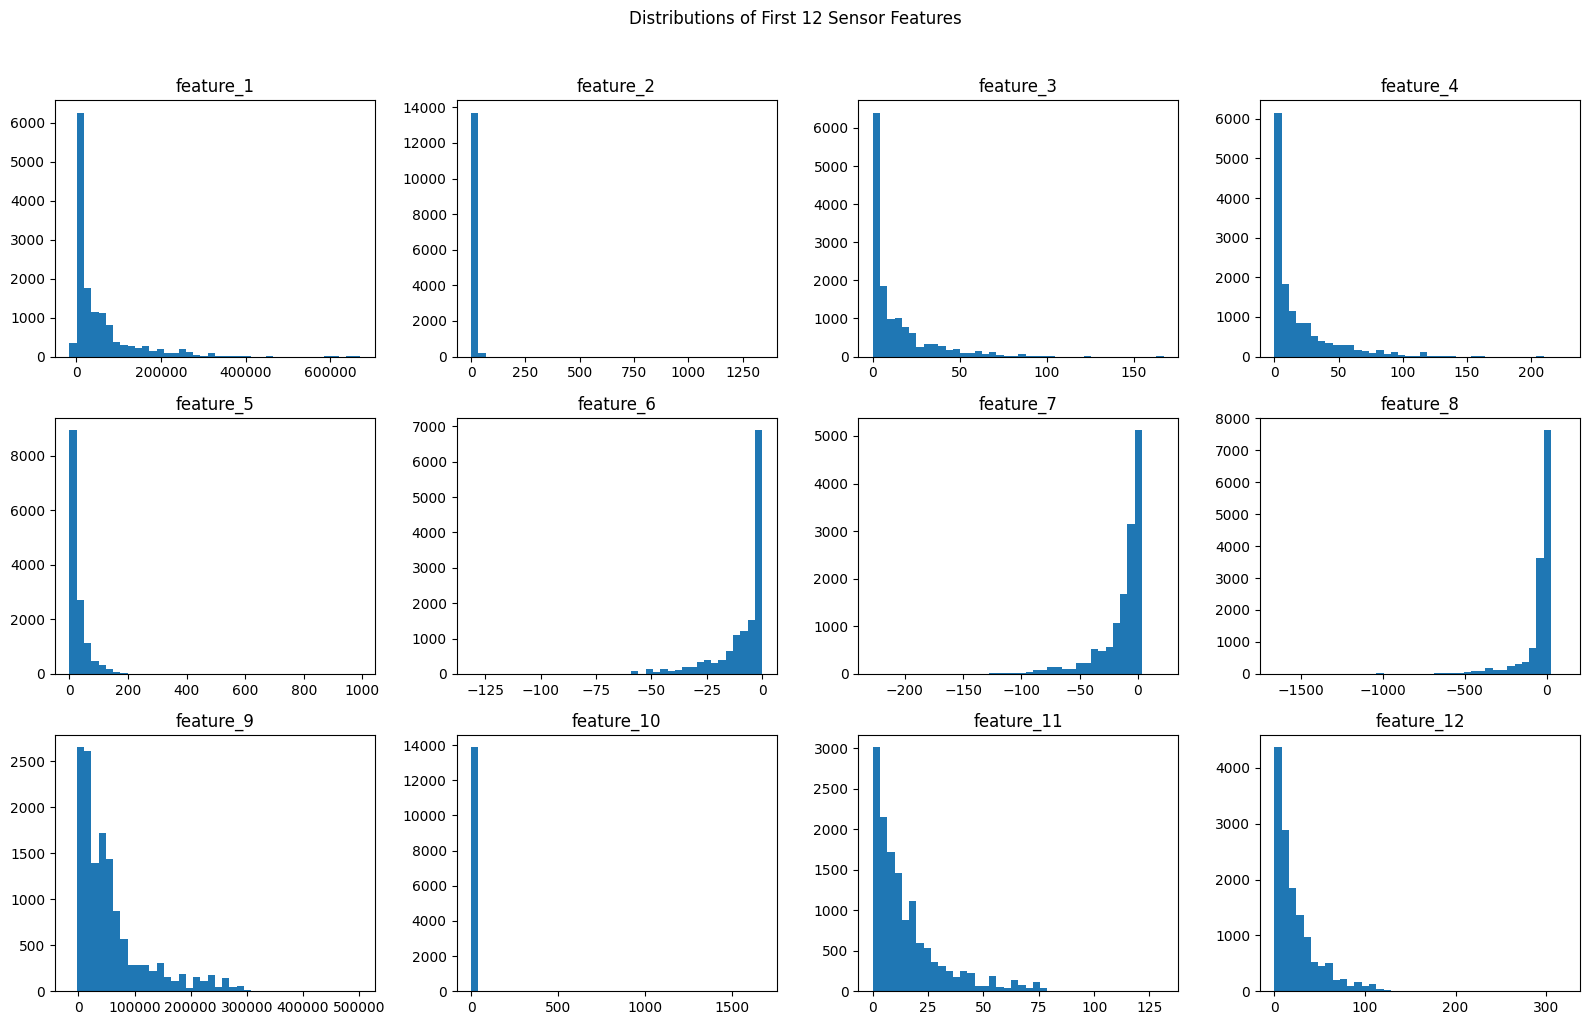

In [ ]:
# 9. First 12 feature distributions
fig, axes = plt.subplots(3, 4, figsize=(16,10))
for ax, col in zip(axes.ravel(), feature_cols[:12]):
    ax.hist(df[col].dropna(), bins=40)
    ax.set_title(col)
plt.suptitle("Distributions of First 12 Sensor Features", y=1.02)
plt.tight_layout()
plt.show()


## 10. Correlation structure

The heatmap is exploratory only. Correlated features will not be removed automatically; dimensionality reduction will be evaluated experimentally.


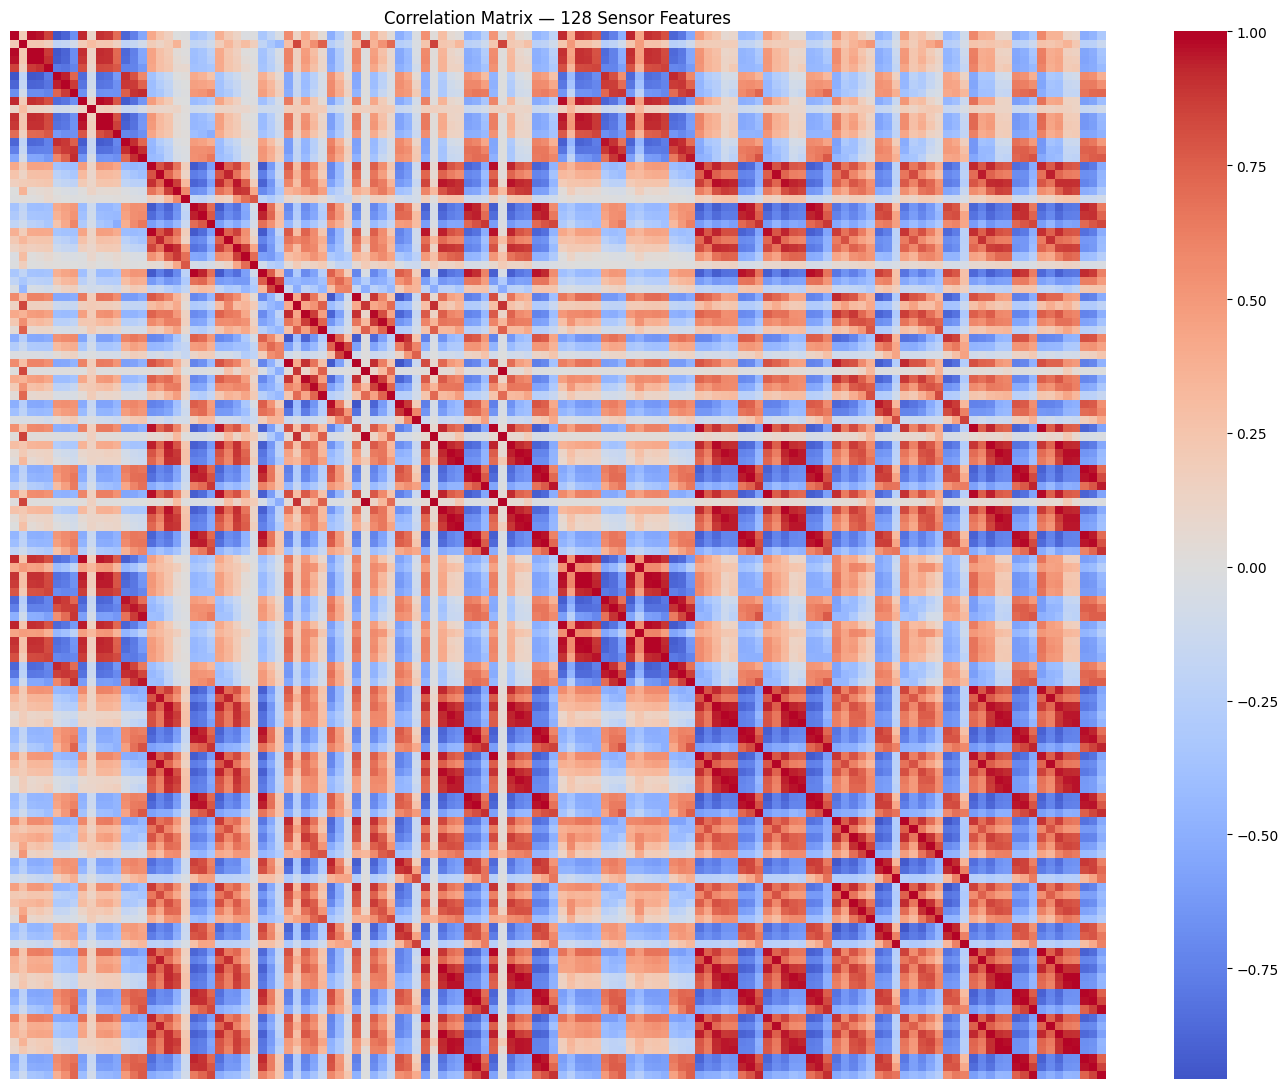

In [ ]:
# 10. Correlation heatmap
corr = df[feature_cols].corr()
plt.figure(figsize=(14,11))
sns.heatmap(corr, cmap="coolwarm", center=0,
            xticklabels=False, yticklabels=False)
plt.title("Correlation Matrix — 128 Sensor Features")
plt.tight_layout()
plt.show()


## 11. PCA exploratory visualisation

PCA is used here only to inspect class separability. The final modelling pipeline must fit PCA using training data only.


PC1 + PC2 explained variance: 68.56 %


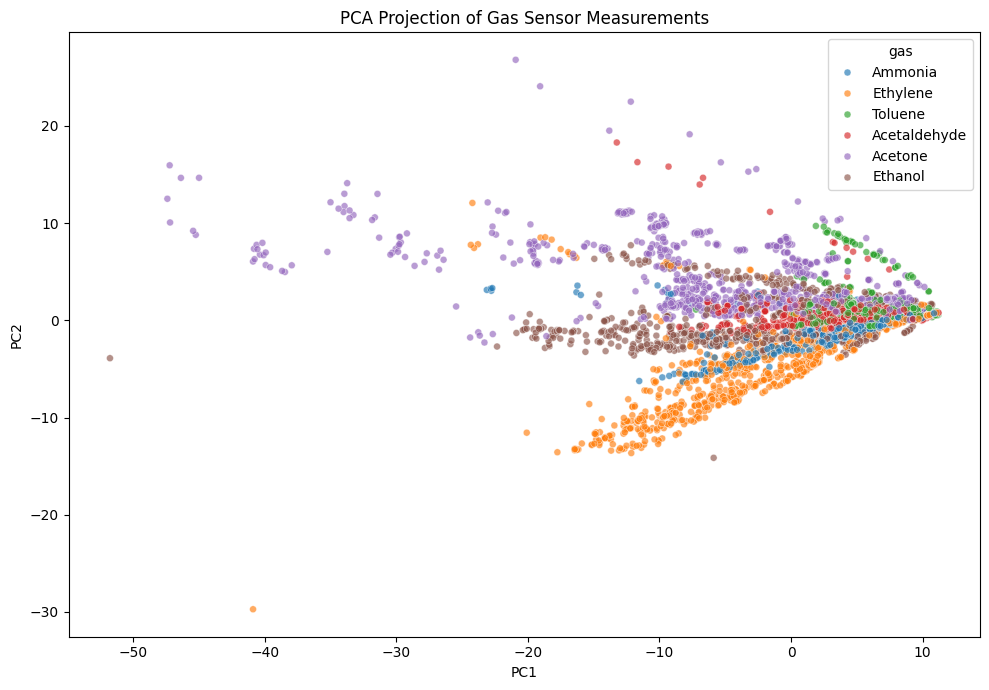

In [ ]:
# 11. PCA 2D exploratory plot
X_raw = df[feature_cols].copy()
y = df["gas"].copy()

eda_scaler = StandardScaler()
X_scaled = eda_scaler.fit_transform(X_raw)

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca2.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "gas": y
})

print("PC1 + PC2 explained variance:",
      round(pca2.explained_variance_ratio_.sum()*100, 2), "%")

sample = plot_df.sample(min(5000, len(plot_df)), random_state=RANDOM_STATE)
plt.figure(figsize=(10,7))
sns.scatterplot(data=sample, x="PC1", y="PC2", hue="gas",
                alpha=0.65, s=25)
plt.title("PCA Projection of Gas Sensor Measurements")
plt.tight_layout()
plt.show()


## 12. PCA explained variance

This identifies candidate component counts for a later PCA-vs-original-feature experiment.


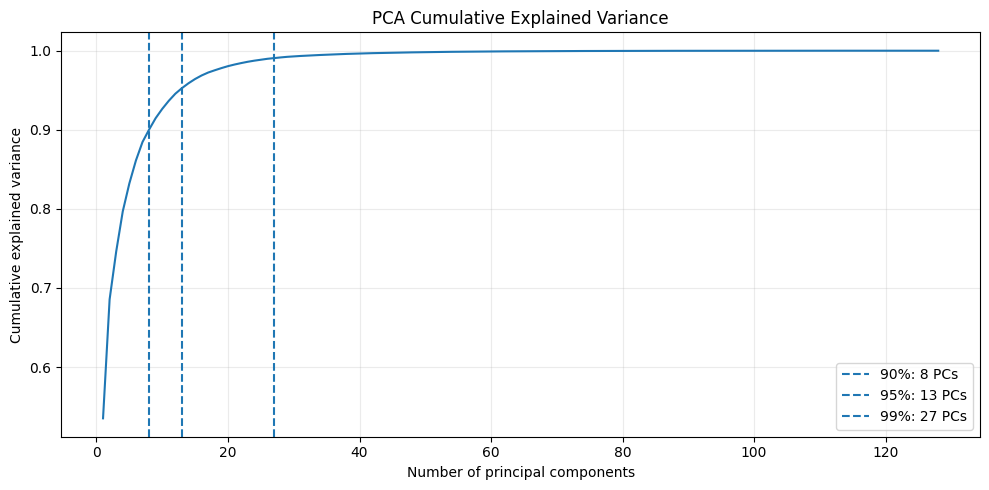

90% variance -> 8 components
95% variance -> 13 components
99% variance -> 27 components


In [ ]:
# 12. Cumulative PCA variance
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10,5))
plt.plot(range(1, len(cum_var)+1), cum_var)
for threshold in [0.90, 0.95, 0.99]:
    n = np.argmax(cum_var >= threshold) + 1
    plt.axvline(n, linestyle="--", label=f"{threshold:.0%}: {n} PCs")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

for threshold in [0.90, 0.95, 0.99]:
    n = np.argmax(cum_var >= threshold) + 1
    print(f"{threshold:.0%} variance -> {n} components")


## 13. Define modelling matrices

**Primary target:** `gas`

**Primary predictors:** 128 sensor-derived features

**Metadata:** `batch`, `class_id`, `concentration_ppmv`

The metadata remains available for drift and experimental-condition analysis but is excluded from the primary classifier.


In [ ]:
# 13. Modelling matrices
X = df[feature_cols].copy()
y = df["gas"].copy()
metadata = df[["batch", "class_id", "concentration_ppmv"]].copy()

print("X:", X.shape)
print("y:", y.shape)
print("Classes:", sorted(y.unique()))


X: (13910, 128)
y: (13910,)
Classes: ['Acetaldehyde', 'Acetone', 'Ammonia', 'Ethanol', 'Ethylene', 'Toluene']


## 14. Standard stratified benchmark split

This is the initial benchmark. A later version should also include a batch-aware split because the dataset contains collection-period structure.


In [ ]:
# 14. Train/test split
X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X, y, metadata,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

comparison = pd.DataFrame({
    "train_%": y_train.value_counts(normalize=True).sort_index()*100,
    "test_%": y_test.value_counts(normalize=True).sort_index()*100
}).round(2)
display(comparison)


Training: (11128, 128)
Testing : (2782, 128)


,train_%,test_%
gas,,
Acetaldehyde,13.92,13.91
Acetone,21.63,21.64
Ammonia,11.80,11.79
Ethanol,18.44,18.44
Ethylene,21.04,21.03
Toluene,13.17,13.19


## 15. Reusable evaluation functions

For the multi-class problem, report:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Weighted F1

Macro F1 is especially useful when comparing performance across all six gases without allowing the largest class to dominate the summary.


In [ ]:
# 15. Evaluation utilities
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

def plot_confusion(y_true, y_pred, title):
    labels = sorted(y_true.unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# V2: model comparison and drift-aware evaluation

This V2 retains V1's reproducible parsing and audit, then evaluates five classifiers using **only the 128 sensor features**. `batch`, `class_id`, and `concentration_ppmv` remain metadata throughout: they are never supplied to a classifier.

The workflow uses a stratified hold-out set for a conventional benchmark, cross-validation inside tuning, and leave-one-batch-out testing to examine sensor drift. The latter is deliberately harder and estimates transfer to an unseen collection batch.

## 16. Experimental guardrails

`sensor_features` is explicitly defined from the V1 schema. The assertions below make accidental inclusion of batch or concentration fail loudly. All learned transformations (imputation, scaling and PCA) live inside pipelines, so they are fit on training folds only.

In [ ]:
# 16. Explicitly enforce the no-metadata predictor rule
sensor_features = [f"feature_{i}" for i in range(1, 129)]
excluded_metadata = {"batch", "class_id", "concentration_ppmv", "gas"}

assert sensor_features == feature_cols
assert not (set(sensor_features) & excluded_metadata)
assert X.columns.tolist() == sensor_features

class_labels = sorted(y.unique())
print(f"Predictors ({len(sensor_features)}): feature_1 ... feature_128")
print("Excluded from every classifier:", ", ".join(sorted(excluded_metadata)))


Predictors (128): feature_1 ... feature_128
Excluded from every classifier: batch, class_id, concentration_ppmv, gas


## 17. Baseline models and timing

The five requested classifiers are benchmarked on the same stratified split. Macro F1 is the primary ranking metric. Fit time, prediction time and serialised model size provide practical computational-cost indicators; they are machine-dependent and should be interpreted comparatively.

In [ ]:
# 17. Pipelines keep preprocessing leakage-free
def make_original_feature_models():
    return {
        "Logistic Regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(C=1.0, max_iter=3000, random_state=RANDOM_STATE)),
        ]),
        "K-Nearest Neighbours": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=5, weights="distance", n_jobs=-1)),
        ]),
        "Decision Tree": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
        ]),
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
            )),
        ]),
        "Support Vector Machine": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVC(C=1.0, kernel="rbf", gamma="scale", cache_size=1000)),
        ]),
    }


def score_predictions(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, labels=class_labels, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, labels=class_labels, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, labels=class_labels, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, labels=class_labels, average="weighted", zero_division=0),
    }


def fit_and_measure(name, estimator, X_fit, y_fit, X_eval, y_eval):
    fit_start = time.perf_counter()
    estimator.fit(X_fit, y_fit)
    fit_seconds = time.perf_counter() - fit_start
    predict_start = time.perf_counter()
    predictions = estimator.predict(X_eval)
    predict_seconds = time.perf_counter() - predict_start
    row = {
        "Model": name,
        **score_predictions(y_eval, predictions),
        "Fit seconds": fit_seconds,
        "Predict seconds": predict_seconds,
        "Model size (MB)": len(pickle.dumps(estimator)) / 1024**2,
    }
    return estimator, predictions, row


  File "c:\Users\srian\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\srian\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\srian\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\srian\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Fit seconds,Predict seconds,Model size (MB)
0,Random Forest,0.9935,0.9940,0.9925,0.9932,0.9935,3.3883,0.0775,17.8529
1,K-Nearest Neighbours,0.9921,0.9927,0.9914,0.9920,0.9921,0.2258,0.1970,10.9590
2,Logistic Regression,0.9896,0.9895,0.9887,0.9891,0.9896,1.1908,0.0070,0.0128
3,Support Vector Machine,0.9820,0.9842,0.9794,0.9816,0.9820,1.7600,0.8731,2.9309
4,Decision Tree,0.9716,0.9706,0.9690,0.9697,0.9716,2.3404,0.0058,0.0578


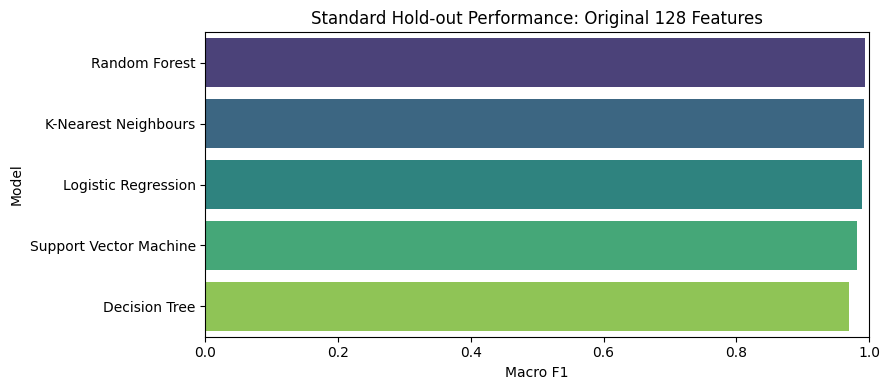

In [ ]:
# 17a. Standard stratified hold-out benchmark (128 original sensor features)
benchmark_rows, benchmark_predictions, fitted_baselines = [], {}, {}
for name, estimator in make_original_feature_models().items():
    fitted, predictions, row = fit_and_measure(name, estimator, X_train, y_train, X_test, y_test)
    fitted_baselines[name] = fitted
    benchmark_predictions[name] = predictions
    benchmark_rows.append(row)

benchmark_results = (
    pd.DataFrame(benchmark_rows)
    .sort_values("Macro F1", ascending=False)
    .reset_index(drop=True)
)
display(benchmark_results.style.format({col: "{:.4f}" for col in benchmark_results.columns if col != "Model"}))

plt.figure(figsize=(9, 4))
sns.barplot(data=benchmark_results, x="Macro F1", y="Model", hue="Model", legend=False, palette="viridis")
plt.xlim(0, 1)
plt.title("Standard Hold-out Performance: Original 128 Features")
plt.tight_layout()
plt.show()


## 18. Original features versus PCA

For a fair comparison, each PCA pipeline learns enough components to explain 95% of training-fold variance. It does not reuse the EDA PCA fitted above, which would leak test information.

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Fit seconds,Predict seconds,Model size (MB),Representation,PCA components
0,Decision Tree,0.9716,0.9706,0.9690,0.9697,0.9716,2.3404,0.0058,0.0578,Original 128 features,128
1,Decision Tree,0.9741,0.9735,0.9706,0.9720,0.9741,0.9944,0.0072,0.0897,PCA (95% training variance),12
2,K-Nearest Neighbours,0.9921,0.9927,0.9914,0.9920,0.9921,0.2258,0.1970,10.9590,Original 128 features,128
3,K-Nearest Neighbours,0.9907,0.9910,0.9902,0.9906,0.9907,0.7531,0.0389,1.3186,PCA (95% training variance),12
4,Logistic Regression,0.9896,0.9895,0.9887,0.9891,0.9896,1.1908,0.0070,0.0128,Original 128 features,128
5,Logistic Regression,0.9209,0.9160,0.9133,0.9145,0.9212,1.4531,0.0074,0.0210,PCA (95% training variance),12
6,Random Forest,0.9935,0.9940,0.9925,0.9932,0.9935,3.3883,0.0775,17.8529,Original 128 features,128
7,Random Forest,0.9925,0.9933,0.9911,0.9921,0.9924,1.9213,0.0905,23.6393,PCA (95% training variance),12
8,Support Vector Machine,0.9820,0.9842,0.9794,0.9816,0.9820,1.7600,0.8731,2.9309,Original 128 features,128
9,Support Vector Machine,0.9558,0.9557,0.9494,0.9520,0.9557,1.8546,0.7735,0.5297,PCA (95% training variance),12


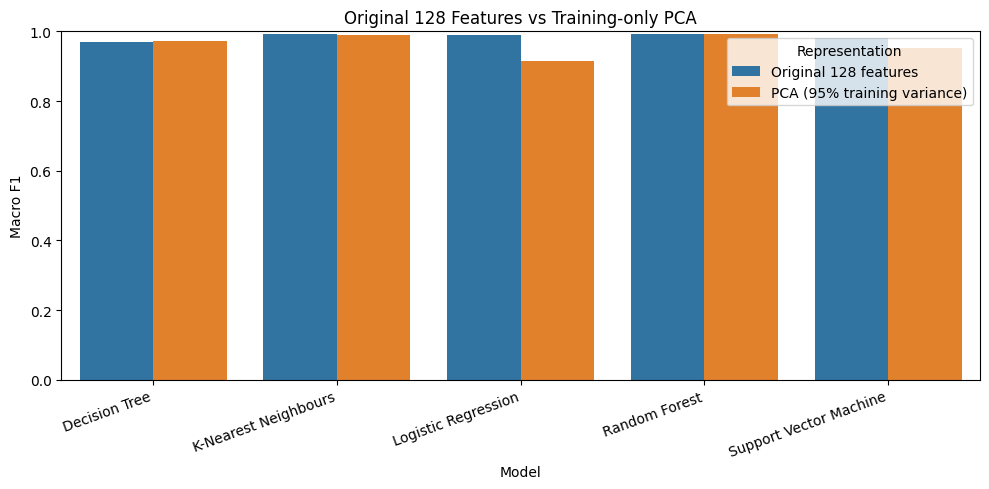

In [ ]:
# 18. Replace feature preprocessing with training-only PCA (95% explained variance)
def make_pca_feature_models():
    models = make_original_feature_models()
    pca_models = {}
    for name, pipeline in models.items():
        steps = [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()),
                 ("pca", PCA(n_components=0.95, svd_solver="full", random_state=RANDOM_STATE))]
        steps.append(("model", pipeline.named_steps["model"]))
        pca_models[name] = Pipeline(steps)
    return pca_models

pca_rows, fitted_pca = [], {}
for name, estimator in make_pca_feature_models().items():
    fitted, predictions, row = fit_and_measure(name, estimator, X_train, y_train, X_test, y_test)
    row["Representation"] = "PCA (95% training variance)"
    row["PCA components"] = fitted.named_steps["pca"].n_components_
    fitted_pca[name] = fitted
    pca_rows.append(row)

original_rows = benchmark_results.copy()
original_rows["Representation"] = "Original 128 features"
original_rows["PCA components"] = 128
representation_results = pd.concat([original_rows, pd.DataFrame(pca_rows)], ignore_index=True)
representation_results = representation_results.sort_values(["Model", "Representation"]).reset_index(drop=True)
display(representation_results.style.format({col: "{:.4f}" for col in ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1", "Fit seconds", "Predict seconds", "Model size (MB)"]}))

plt.figure(figsize=(10, 5))
sns.barplot(data=representation_results, x="Model", y="Macro F1", hue="Representation")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.title("Original 128 Features vs Training-only PCA")
plt.tight_layout()
plt.show()


## 19. Hyperparameter tuning

Randomised search controls runtime while exploring model-specific choices. The search uses only the training partition with stratified 3-fold cross-validation, optimising macro F1. The untouched test set is evaluated once after each search.

In [ ]:
# 19. Compact, reproducible tuning searches on original sensor features only
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
param_distributions = {
    "Logistic Regression": {
        "model__C": np.logspace(-3, 2, 12),
        "model__class_weight": [None, "balanced"],
    },
    "K-Nearest Neighbours": {
        "model__n_neighbors": list(range(3, 32, 2)),
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],
    },
    "Decision Tree": {
        "model__criterion": ["gini", "entropy", "log_loss"],
        "model__max_depth": [None, 5, 10, 20, 35],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 5, 10],
    },
    "Random Forest": {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 10, 20, 35],
        "model__min_samples_leaf": [1, 2, 5],
        "model__max_features": ["sqrt", "log2", 0.5],
    },
    "Support Vector Machine": {
        "model__C": np.logspace(-2, 2, 12),
        "model__gamma": ["scale", "auto", *np.logspace(-4, -1, 8)],
    },
}

tuning_rows, tuned_estimators, tuned_predictions = [], {}, {}
for name, estimator in make_original_feature_models().items():
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_distributions[name],
        n_iter=10,
        scoring="f1_macro",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
        return_train_score=False,
    )
    search_start = time.perf_counter()
    search.fit(X_train, y_train)
    search_seconds = time.perf_counter() - search_start
    test_start = time.perf_counter()
    predictions = search.predict(X_test)
    test_seconds = time.perf_counter() - test_start
    tuned_estimators[name] = search.best_estimator_
    tuned_predictions[name] = predictions
    tuning_rows.append({
        "Model": name,
        "CV Macro F1": search.best_score_,
        **score_predictions(y_test, predictions),
        "Search seconds": search_seconds,
        "Test prediction seconds": test_seconds,
        "Best parameters": search.best_params_,
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values("Macro F1", ascending=False).reset_index(drop=True)
display(tuning_results.style.format({col: "{:.4f}" for col in ["CV Macro F1", "Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1", "Search seconds", "Test prediction seconds"]}))


,Model,CV Macro F1,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Search seconds,Test prediction seconds,Best parameters
0,K-Nearest Neighbours,0.9942,0.9957,0.9961,0.9950,0.9955,0.9957,9.5261,0.3857,"{'model__weights': 'distance', 'model__p': 1, 'model__n_neighbors': 5}"
1,Support Vector Machine,0.9934,0.9942,0.9951,0.9930,0.9940,0.9943,49.7270,0.2955,"{'model__gamma': 0.013894954943731374, 'model__C': 43.287612810830616}"
2,Random Forest,0.9928,0.9935,0.9940,0.9925,0.9932,0.9935,142.4697,0.2062,"{'model__n_estimators': 600, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 35}"
3,Logistic Regression,0.9907,0.9907,0.9911,0.9897,0.9904,0.9907,9.7750,0.0073,"{'model__class_weight': None, 'model__C': 12.32846739442066}"
4,Decision Tree,0.9620,0.9633,0.9627,0.9596,0.9610,0.9633,8.5016,0.0056,"{'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': None, 'model__criterion': 'gini'}"


## 20. Per-class performance and confusion matrices

The tuned model with the highest test macro F1 is reported in detail. Per-class recall highlights gases that the overall score can conceal, and the normalised confusion matrix makes error patterns comparable across classes.

Champion selected by held-out Macro F1: K-Nearest Neighbours


,precision,recall,f1-score,support
Acetaldehyde,0.9974,0.9948,0.9961,387
Acetone,0.9901,0.9983,0.9942,602
Ammonia,1.0000,0.9848,0.9923,328
Ethanol,0.9981,0.9981,0.9981,513
Ethylene,0.9966,0.9966,0.9966,585
Toluene,0.9946,0.9973,0.9959,367


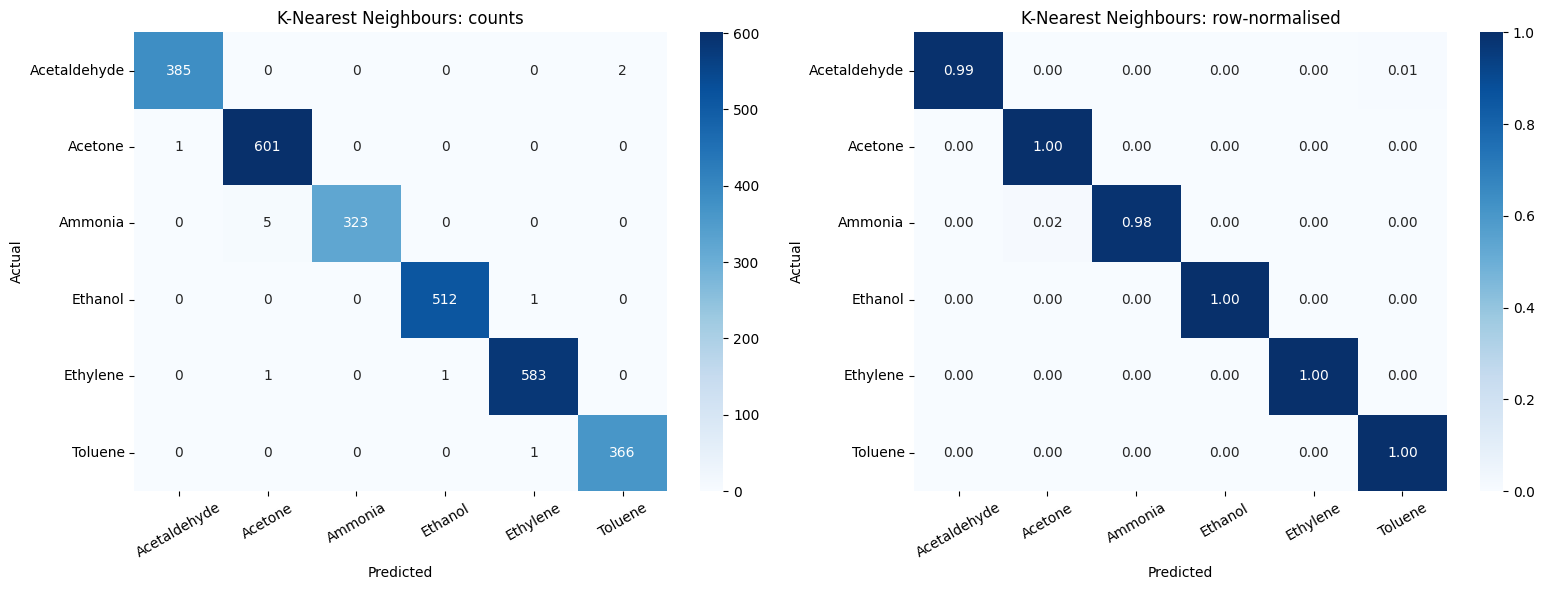

In [ ]:
# 20. Detailed diagnostics for the best tuned model
champion_name = tuning_results.iloc[0]["Model"]
champion = tuned_estimators[champion_name]
champion_predictions = tuned_predictions[champion_name]
print("Champion selected by held-out Macro F1:", champion_name)

per_class = pd.DataFrame(
    classification_report(y_test, champion_predictions, labels=class_labels, output_dict=True, zero_division=0)
).T.loc[class_labels, ["precision", "recall", "f1-score", "support"]]
display(per_class.style.format({"precision": "{:.4f}", "recall": "{:.4f}", "f1-score": "{:.4f}", "support": "{:.0f}"}))

cm = confusion_matrix(y_test, champion_predictions, labels=class_labels)
cm_normalised = confusion_matrix(y_test, champion_predictions, labels=class_labels, normalize="true")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set(title=f"{champion_name}: counts", xlabel="Predicted", ylabel="Actual")
sns.heatmap(cm_normalised, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
axes[1].set(title=f"{champion_name}: row-normalised", xlabel="Predicted", ylabel="Actual")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()


## 21. Batch-aware evaluation for sensor drift

Leave-one-batch-out validation trains on all other batches and tests on the held-out batch. `batch` identifies the split only and is not a model input. This result should be compared with the random stratified benchmark: a substantial decline indicates sensitivity to batch-to-batch drift.

,Held-out batch,Test rows,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Fit seconds
0,1,445,0.8270,0.7140,0.7349,0.7110,0.8049,0.2875
1,2,1244,0.9711,0.8194,0.8356,0.8251,0.9719,0.2690
2,3,1586,0.9748,0.8104,0.8130,0.8114,0.9755,0.2532
3,4,161,0.8012,0.7309,0.7192,0.7104,0.8142,0.2855
4,5,197,0.9848,0.8237,0.8140,0.8184,0.9846,0.2822
5,6,2300,0.9730,0.9383,0.9700,0.9502,0.9734,0.2403
6,7,3613,0.8356,0.8493,0.8248,0.8240,0.8245,0.1995
7,8,294,0.9592,0.9718,0.9509,0.9584,0.9578,0.2969
8,9,470,0.9681,0.9654,0.9736,0.9683,0.9680,0.2922
9,10,3600,0.6231,0.6499,0.6231,0.6250,0.6250,0.2134


Batch-aware mean Macro F1: 0.8202
Random hold-out champion Macro F1: 0.9955


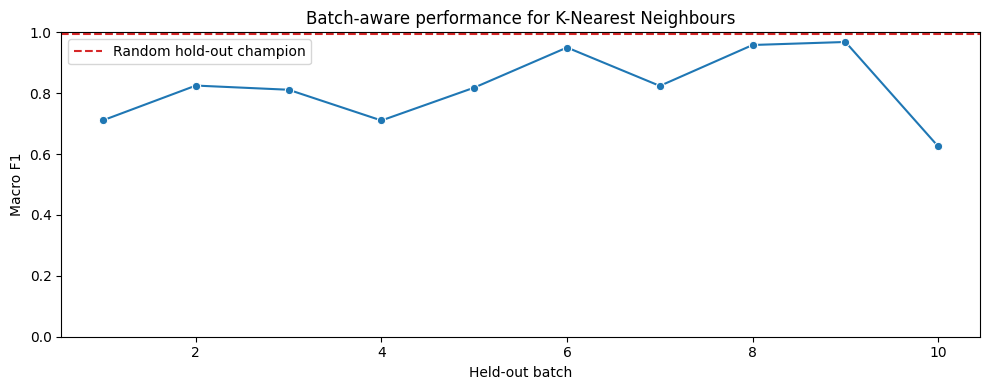

In [ ]:
# 21. Sensor-drift evaluation: hold out one entire batch at a time
logo = LeaveOneGroupOut()
batch_rows = []
for train_idx, test_idx in logo.split(X, y, groups=metadata["batch"]):
    held_out_batch = int(metadata.iloc[test_idx]["batch"].iloc[0])
    batch_model = clone(champion)
    fit_start = time.perf_counter()
    batch_model.fit(X.iloc[train_idx], y.iloc[train_idx])
    fit_seconds = time.perf_counter() - fit_start
    predictions = batch_model.predict(X.iloc[test_idx])
    batch_rows.append({
        "Held-out batch": held_out_batch,
        "Test rows": len(test_idx),
        **score_predictions(y.iloc[test_idx], predictions),
        "Fit seconds": fit_seconds,
    })

batch_results = pd.DataFrame(batch_rows).sort_values("Held-out batch").reset_index(drop=True)
display(batch_results.style.format({col: "{:.4f}" for col in ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1", "Fit seconds"]}))

print("Batch-aware mean Macro F1:", f"{batch_results['Macro F1'].mean():.4f}")
print("Random hold-out champion Macro F1:", f"{tuning_results.iloc[0]['Macro F1']:.4f}")

plt.figure(figsize=(10, 4))
sns.lineplot(data=batch_results, x="Held-out batch", y="Macro F1", marker="o")
plt.axhline(tuning_results.iloc[0]["Macro F1"], color="tab:red", linestyle="--", label="Random hold-out champion")
plt.ylim(0, 1)
plt.title(f"Batch-aware performance for {champion_name}")
plt.legend()
plt.tight_layout()
plt.show()


## 22. Conclusions and reporting checklist
Note:
Use the generated tables to report the selected model, its held-out macro F1, the PCA trade-off, per-class weaknesses, and the gap between random and batch-aware evaluation. Do not claim batch-aware performance as a deployment estimate without considering whether future batches also differ in concentration, environment or acquisition protocol.

**Feature-policy confirmation:** every estimator in this notebook receives `feature_1` through `feature_128` only. `batch` is used solely for grouping in Section 21; `concentration_ppmv` is never used for fitting, selection or prediction.